In [2]:
import pandas as pd

##### Data Access
- use the R notebook for the AWS access. Credentials are defualt accepted in Python.

##### Loyalty CSV

In [3]:
df = pd.read_csv("bladder.csv")
df.head()

,id,rx,number,size,start,stop,event,enum
0,1,1,1,3,0,1,0,1
1,2,1,2,1,0,4,0,1
2,3,1,1,1,0,7,0,1
3,4,1,5,1,0,10,0,1
4,5,1,4,1,0,6,1,1


#### 1.Survival Curves

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lifelines
from sksurv.nonparametric import kaplan_meier_estimator
from lifelines import KaplanMeierFitter
from lifelines import NelsonAalenFitter

simple=pd.DataFrame(data={'Censored': [1,1,0,1,1,0], 'Tenure': [7,8,10,3,2,3]})
km = KaplanMeierFitter()

km.fit(durations = simple['Tenure'],event_observed=simple['Censored'])

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 6 total observations, 2 right-censored observations>

##### Event Table

In [11]:
km.event_table

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,0,0,0,6,6
2.0,1,1,0,0,6
3.0,2,1,1,0,5
7.0,1,1,0,0,3
8.0,1,1,0,0,2
10.0,1,0,1,0,1


##### Timeline Estimate

In [12]:
km.survival_function_

,KM_estimate
timeline,
0.0,1.000000
2.0,0.833333
3.0,0.666667
7.0,0.444444
8.0,0.222222
10.0,0.222222


##### Survival Curves

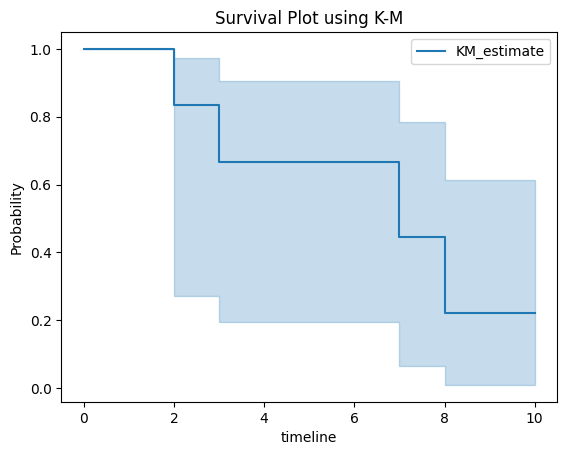

In [13]:
km.plot()
plt.title("Survival Plot using K-M")
plt.ylabel("Probability")
plt.show()

<Axes: xlabel='timeline'>

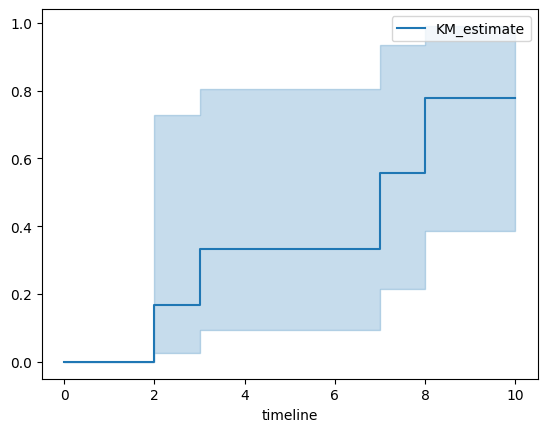

In [15]:
km.plot_cumulative_density()

#### 2.Stratified Analysis

In [31]:
loyalty=pd.read_csv("loyalty.csv")

cen_loy=loyalty["censored"]
time_loy=loyalty["Tenure"]

loy = (loyalty["Loyalty"] == 0)
kmf = KaplanMeierFitter()
kmf.fit(time_loy[loy], event_observed=cen_loy[loy], label="No program")

<lifelines.KaplanMeierFitter:"No program", fitted with 183 total observations, 116 right-censored observations>

In [32]:
loyalty.head()

,Income,Age,Loyalty,censored,Tenure
0,51,45,0,1,22
1,41,33,0,1,9
2,52,35,0,1,1
3,48,40,0,0,9
4,56,41,0,1,2


In [33]:
kmf.plot_survival_function(ax=ax)

kmf.fit(time_loy[~loy], event_observed=cen_loy[~loy], label="Program members")

<lifelines.KaplanMeierFitter:"Program members", fitted with 67 total observations, 28 right-censored observations>

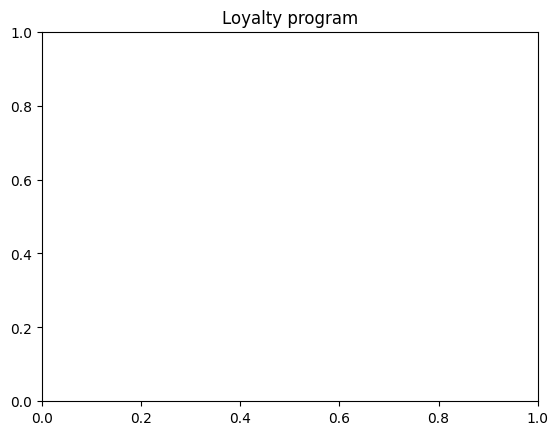

In [34]:
kmf.plot_survival_function(ax=ax)

plt.title("Loyalty program")
plt.show()

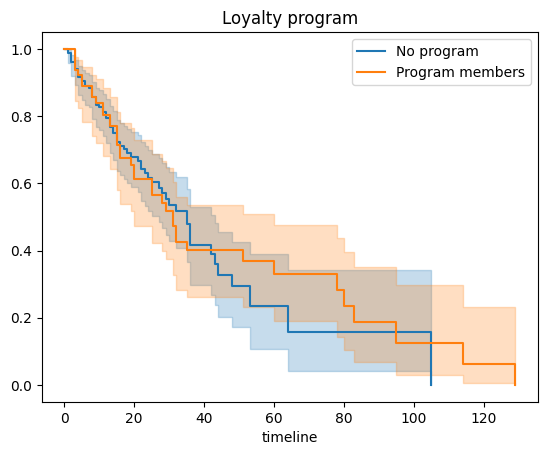

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Load the dataset
loyalty = pd.read_csv("loyalty.csv")

# Extract relevant columns
cen_loy = loyalty["censored"]
time_loy = loyalty["Tenure"]

# Define groups
loy = (loyalty["Loyalty"] == 0)

# Initialize the plot
fig, ax = plt.subplots()

# Kaplan-Meier Fitter instance
kmf = KaplanMeierFitter()

# Fit and plot for "No program" group
kmf.fit(time_loy[loy], event_observed=cen_loy[loy], label="No program")
kmf.plot_survival_function(ax=ax)

# Fit and plot for "Program members" group
kmf.fit(time_loy[~loy], event_observed=cen_loy[~loy], label="Program members")
kmf.plot_survival_function(ax=ax)

# Add title and display the plot
plt.title("Loyalty program")
plt.show()


Recidivism Data Set

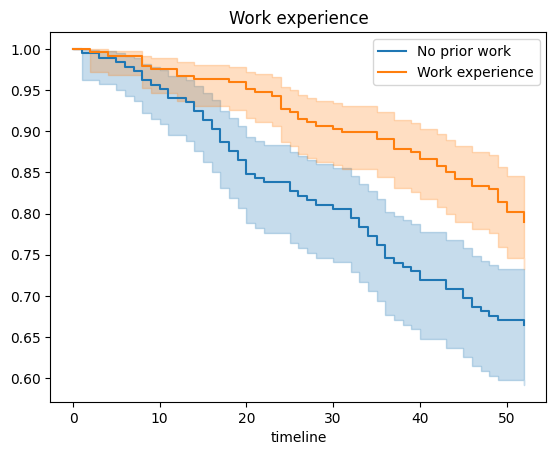

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

recid = pd.read_csv("recid.csv")

cen_recid=recid["arrest"]
time_recid=recid["week"]

# Define groups
no_work = (recid["wexp"] == 0)

# Initialize the plot
fig, ax = plt.subplots()

# Kaplan-Meier Fitter instance
kmf = KaplanMeierFitter()

# Fit and plot for "No program" group
kmf.fit(time_recid[no_work], event_observed=cen_recid[no_work], label="No prior work")
kmf.plot_survival_function(ax=ax)

# Fit and plot for "Program members" group
kmf.fit(time_recid[~no_work], event_observed=cen_recid[~no_work], label="Work experience")
kmf.plot_survival_function(ax=ax)


# Add title and display the plot
plt.title("Work experience")
plt.show()


In [26]:
results = logrank_test(time_recid[no_work], time_recid[~no_work], cen_recid[no_work], cen_recid[~no_work], alpha=.99)

results.print_summary()

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.99
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
           9.91 <0.005      9.25

In [27]:
## There is also a multivariate_logrank_test for when you have more than two groups to compare and a pairwise_logrank_test to do multiple comparisons.


results = logrank_test(time_recid[no_work], time_recid[~no_work], cen_recid[no_work], cen_recid[~no_work], weightings="wilcoxon",alpha=.99)

results.print_summary()

<lifelines.StatisticalResult: Wilcoxon_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.99
         test_name = Wilcoxon_test

---
 test_statistic      p  -log2(p)
          10.98 <0.005     10.09

#### 3.Hazard Functions
- Rates: these are distributions
- Probabilities: these are observed proportions, called probabilites

In [37]:
km_val = km.event_table

hazard = km_val.observed/km_val.at_risk

hazard

event_at
0.0     0.000000
2.0     0.166667
3.0     0.200000
7.0     0.333333
8.0     0.500000
10.0    0.000000
dtype: float64

In [38]:
cum_haz=NelsonAalenFitter()
cum_haz.fit(durations = simple['Tenure'],event_observed=simple['Censored'])

<lifelines.NelsonAalenFitter:"NA_estimate", fitted with 6 total observations, 2 right-censored observations>

<Axes: xlabel='timeline'>

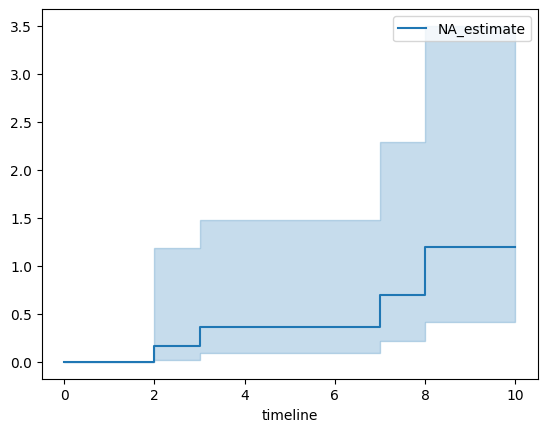

In [39]:
cum_haz.plot_cumulative_hazard()

#### 4.Accelerated Failure Time Models
- Regression model

In [40]:
from lifelines import WeibullAFTFitter
# Recidivism dataset

recid1=recid[['fin','age','wexp','mar','paro','prio','week','arrest']]
aft = WeibullAFTFitter()
aft.fit(recid1, duration_col='week', event_col='arrest',ancillary=False )
aft.print_summary(3)

<lifelines.WeibullAFTFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
   number of observations = 432
number of events observed = 114
           log-likelihood = -680.485
         time fit was run = 2024-10-30 14:02:37 UTC

---
                    coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
param   covariate                                                                                                         
lambda_ age        0.040      1.041      0.016            0.009            0.071                1.009                1.074
        fin        0.262      1.300      0.138           -0.007            0.532                0.993                1.703
        mar        0.339      1.403      0.273           -0.195            0.873                0.823                2.394
        paro       0.054      1.055      0.139           -0.219            0.327                0.803                1.387
        prio      -0.065      0.937      0.021           -0.106           -0.023                0.900                0.977
        wexp       0.112      1.118      0.152           -0.186            0.409                0.831                1.505
        Intercept  3.809     45.086      0.376            3.071            4.546               21.569               94.241
rho_    Intercept  0.338      1.403      0.089            0.164            0.513                1.178                1.670

                    cmp to      z       p   -log2(p)
param   covariate                                   
lambda_ age          0.000  2.509   0.012      6.368
        fin          0.000  1.907   0.056      4.146
        mar          0.000  1.244   0.214      2.227
        paro         0.000  0.386   0.700      0.515
        prio         0.000 -3.078   0.002      8.907
        wexp         0.000  0.736   0.462      1.114
        Intercept    0.000 10.124 <0.0005     77.620
rho_    Intercept    0.000  3.797 <0.0005     12.736
---
Concordance = 0.639
AIC = 1376.971
log-likelihood ratio test = 32.278 on 6 df
-log2(p) of ll-ratio test = 16.080

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

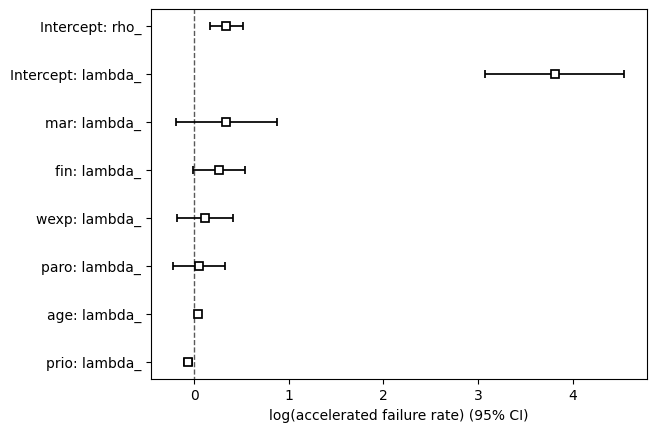

In [41]:
aft.plot()

#### Weibull Distribution

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import WeibullAFTFitter

recid1=recid[['fin','age','wexp','mar','paro','prio','week','arrest']]
aft = WeibullAFTFitter()
aft.fit(recid1, duration_col='week', event_col='arrest',ancillary=False )

<lifelines.WeibullAFTFitter: fitted with 432 total observations, 318 right-censored observations>

In [43]:
aft.print_summary(3)

<lifelines.WeibullAFTFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
   number of observations = 432
number of events observed = 114
           log-likelihood = -680.485
         time fit was run = 2024-11-01 17:19:48 UTC

---
                    coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
param   covariate                                                                                                         
lambda_ age        0.040      1.041      0.016            0.009            0.071                1.009                1.074
        fin        0.262      1.300      0.138           -0.007            0.532                0.993                1.703
        mar        0.339      1.403      0.273           -0.195            0.873                0.823                2.394
        paro       0.054      1.055      0.139           -0.219            0.327                0.803                1.387
        prio      -0.065      0.937      0.021           -0.106           -0.023                0.900                0.977
        wexp       0.112      1.118      0.152           -0.186            0.409                0.831                1.505
        Intercept  3.809     45.086      0.376            3.071            4.546               21.569               94.241
rho_    Intercept  0.338      1.403      0.089            0.164            0.513                1.178                1.670

                    cmp to      z       p   -log2(p)
param   covariate                                   
lambda_ age          0.000  2.509   0.012      6.368
        fin          0.000  1.907   0.056      4.146
        mar          0.000  1.244   0.214      2.227
        paro         0.000  0.386   0.700      0.515
        prio         0.000 -3.078   0.002      8.907
        wexp         0.000  0.736   0.462      1.114
        Intercept    0.000 10.124 <0.0005     77.620
rho_    Intercept    0.000  3.797 <0.0005     12.736
---
Concordance = 0.639
AIC = 1376.971
log-likelihood ratio test = 32.278 on 6 df
-log2(p) of ll-ratio test = 16.080

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

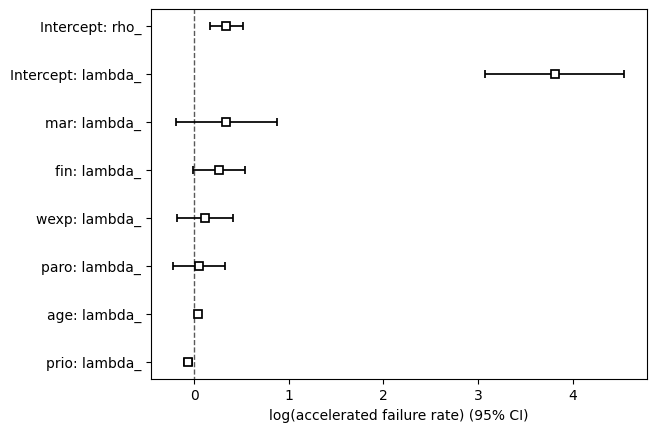

In [44]:
aft.plot()

#### Log Logistic Distribution

In [45]:
from lifelines import LogLogisticAFTFitter

aft = LogLogisticAFTFitter()
aft.fit(recid1, duration_col='week', event_col='arrest' )

<lifelines.LogLogisticAFTFitter: fitted with 432 total observations, 318 right-censored observations>

In [46]:
aft.print_summary(3)

<lifelines.LogLogisticAFTFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
   number of observations = 432
number of events observed = 114
           log-likelihood = -680.725
         time fit was run = 2024-11-01 17:21:07 UTC

---
                   coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
param  covariate                                                                                                         
alpha_ age        0.036      1.036      0.016            0.005            0.066                1.005                1.068
       fin        0.277      1.319      0.145           -0.008            0.562                0.992                1.754
       mar        0.373      1.453      0.271           -0.158            0.905                0.854                2.472
       paro       0.037      1.038      0.149           -0.255            0.330                0.775                1.391
       prio      -0.066      0.936      0.023           -0.111           -0.022                0.895                0.978
       wexp       0.191      1.210      0.157           -0.118            0.500                0.889                1.648
       Intercept  3.691     40.069      0.383            2.939            4.442               18.906               84.920
beta_  Intercept  0.432      1.540      0.087            0.262            0.602                1.300                1.825

                   cmp to      z       p   -log2(p)
param  covariate                                   
alpha_ age          0.000  2.289   0.022      5.500
       fin          0.000  1.903   0.057      4.133
       mar          0.000  1.377   0.169      2.568
       paro         0.000  0.249   0.803      0.316
       prio         0.000 -2.931   0.003      8.210
       wexp         0.000  1.213   0.225      2.150
       Intercept    0.000  9.630 <0.0005     70.507
beta_  Intercept    0.000  4.993 <0.0005     20.685
---
Concordance = 0.643
AIC = 1377.450
log-likelihood ratio test = 31.899 on 6 df
-log2(p) of ll-ratio test = 15.839

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

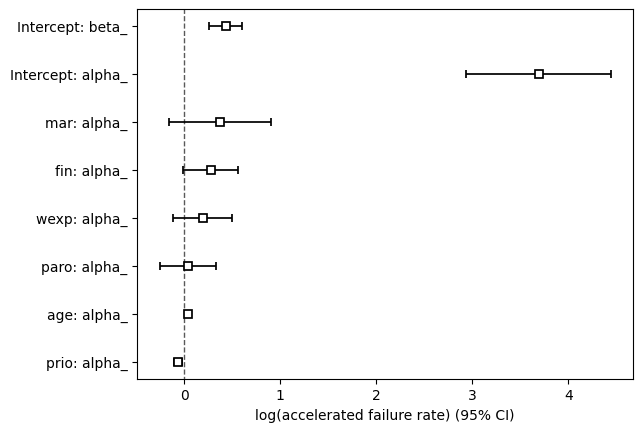

In [47]:
aft.plot()

#### 5.Cox Regression Model - Proportional Hazard Model

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

recid_ph=recid[['fin','age', 'prio','arrest','week']]
cph = CoxPHFitter()
cph.fit(recid_ph, duration_col='week', event_col='arrest')

<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>

In [49]:
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
      baseline estimation = breslow
   number of observations = 432
number of events observed = 114
   partial log-likelihood = -660.86
         time fit was run = 2024-11-04 16:30:36 UTC

---
            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                         
fin        -0.35       0.71       0.19            -0.72             0.03                 0.49                 1.03
age        -0.07       0.94       0.02            -0.11            -0.03                 0.90                 0.97
prio        0.10       1.10       0.03             0.04             0.15                 1.04                 1.16

            cmp to     z      p   -log2(p)
covariate                                 
fin           0.00 -1.82   0.07       3.87
age           0.00 -3.22 <0.005       9.60
prio          0.00  3.56 <0.005      11.37
---
Concordance = 0.63
Partial AIC = 1327.71
log-likelihood ratio test = 29.05 on 3 df
-log2(p) of ll-ratio test = 18.80

<Axes: xlabel='log(HR) (95% CI)'>

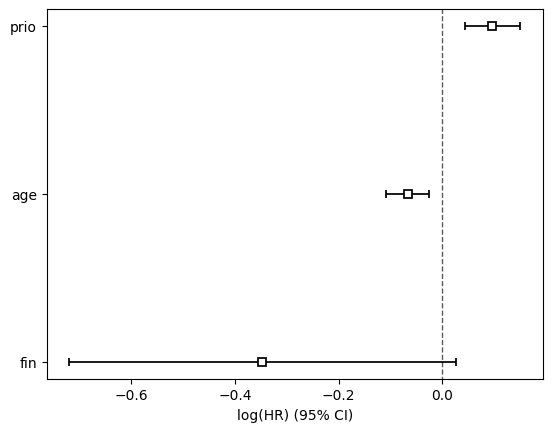

In [50]:

cph.plot()

<Axes: >

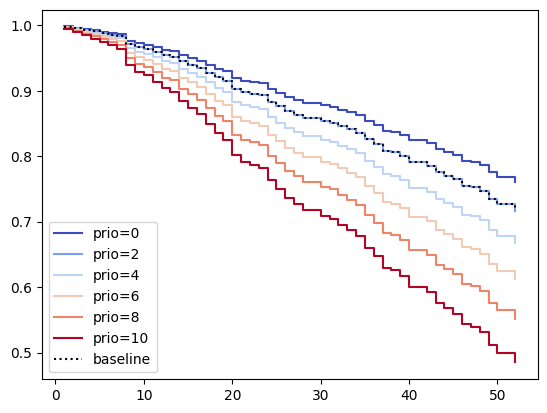

In [51]:
cph.plot_partial_effects_on_outcome(covariates='prio', values=[0, 2, 4, 6, 8, 10], cmap='coolwarm')


##### Model Assessment

In [52]:
cph.check_assumptions(recid_ph, p_value_threshold = 0.05)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
         test_name = proportional_hazard_test

---
           test_statistic    p  -log2(p)
age  km              6.29 0.01      6.37
     rank            6.62 0.01      6.63
fin  km              0.00 1.00      0.01
     rank            0.00 0.98      0.03
prio km              0.82 0.37      1.45
     rank            0.77 0.38      1.40



1. Variable 'age' failed the non-proportional test: p-value is 0.0101.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varyi

[]

In [56]:
recid.columns

Index(['week', 'arrest', 'fin', 'age', 'race', 'wexp', 'mar', 'paro', 'prio',
       'educ', 'emp1', 'emp2', 'emp3', 'emp4', 'emp5', 'emp6', 'emp7', 'emp8',
       'emp9', 'emp10', 'emp11', 'emp12', 'emp13', 'emp14', 'emp15', 'emp16',
       'emp17', 'emp18', 'emp19', 'emp20', 'emp21', 'emp22', 'emp23', 'emp24',
       'emp25', 'emp26', 'emp27', 'emp28', 'emp29', 'emp30', 'emp31', 'emp32',
       'emp33', 'emp34', 'emp35', 'emp36', 'emp37', 'emp38', 'emp39', 'emp40',
       'emp41', 'emp42', 'emp43', 'emp44', 'emp45', 'emp46', 'emp47', 'emp48',
       'emp49', 'emp50', 'emp51', 'emp52', 'New_educ'],
      dtype='object')

In [57]:
recid2 = pd.read_csv("recid.csv")

In [58]:
from lifelines import CoxTimeVaryingFitter

recid_long=recid2[['fin', 'age', 'prio', 'employed','start','stop','subj','arrested']]
ctv = CoxTimeVaryingFitter()
ctv.fit(recid_long, id_col="subj", event_col="arrested", start_col="start", stop_col="stop", show_progress=True)

KeyError: "['employed', 'start', 'stop', 'subj', 'arrested'] not in index"

#### Marker


In [ ]:
files <- get_bucket_df(
  bucket = "s3://survival2024/",
  region = "us-east-1",
  max = 20000
) %>%
  as_tibble()

#Downloading files
save_object(
  object = "bladder.csv",
  bucket = "s3://survival2024/",
  region = "us-east-1",
  file = "bladder"
)